# Práctica guiada: Procesamiento digital de imágenes

Esta práctica funciona como puente entre los cuadernos conceptuales y el laboratorio aplicado. La propuesta es que completes código, pruebes variantes y expliques con tus palabras qué decisiones tomaste.

## Objetivos

- Recuperar ideas de color, canales, bordes e intensidad.
- Practicar lectura de imágenes con `OpenCV`.
- Resolver consignas breves con andamiaje.
- Prepararte para el laboratorio de segmentación y la actividad integradora.


In [ ]:
#mportaciones y funciones auxiliares

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import skimage as ski
#se define la función para mostrar varias imagénes juntas
def mostrar_imagenes(imagenes, titulos, cmap=None, figsize=(14, 4)):
    fig, axes = plt.subplots(1, len(imagenes), figsize=figsize) #crea una fila con varias imágenes
    if len(imagenes) == 1:
        axes = [axes]

    for ax, imagen, titulo in zip(axes, imagenes, titulos):
        if imagen.ndim == 2: #verifica si la imagen es de 2 dimensiones (escala de grises)
            ax.imshow(imagen, cmap=cmap or "gray")
        else:
            ax.imshow(imagen)
        ax.set_title(titulo)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

#se define la función para hacer una segmentacion por umbral
def segmentar_por_umbral(imagen, umbral):
    mascara = np.zeros_like(imagen, dtype=np.uint8)
    mascara[imagen > umbral] = 255
    return mascara


In [ ]:
#Genera automáticamente 3 imágenes de ejemplo y las guarda como archivos
base = Path(".")

cv2.imwrite(str(base / "paisaje.png"), cv2.cvtColor(ski.data.astronaut(), cv2.COLOR_RGB2BGR))
cv2.imwrite(str(base / "texto.png"), ski.data.page())
cv2.imwrite(str(base / "monedas.png"), ski.data.coins())

print("Archivos de práctica listos: paisaje.png, texto.png y monedas.png")


Archivos de práctica listos: paisaje.png, texto.png y monedas.png


## Ejercicio 1: Color y canales

Completá los pasos.

1. Cargá `paisaje.png` con `OpenCV`.
2. Convertí la imagen a `RGB`.
3. Extraé los tres canales.
4. Mostrá la imagen original y los canales por separado.
5. Escribí una observación breve sobre qué zonas se destacan en cada canal.


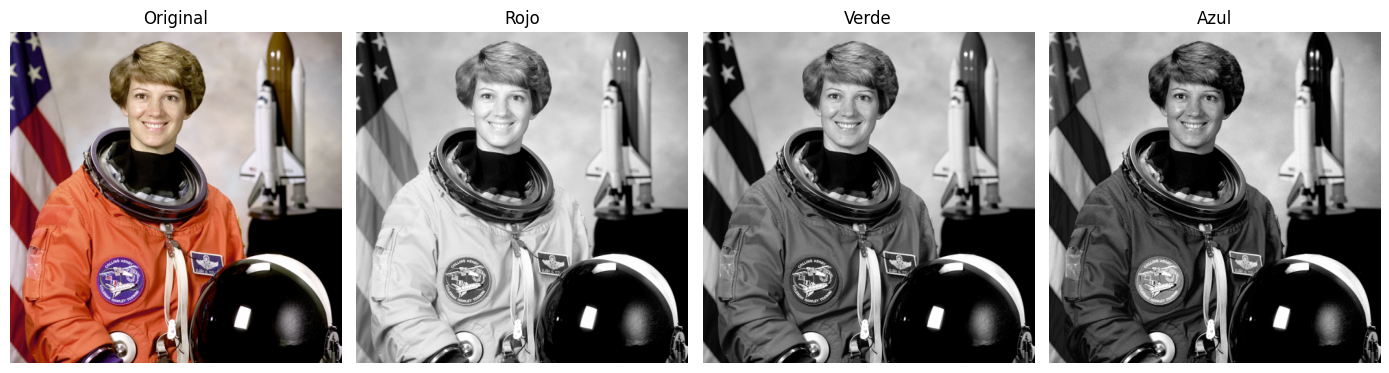

In [ ]:
# 1. Cargar la imagen
img_bgr = cv2.imread("paisaje.png")

# 2. Convertirla a RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) #OpenCV guarda y lee imágenes en formato BGR, no RGB

# 3. Extraer canales ¨[ filas:columnas:canales]
canal_rojo = img_rgb[:, :, 0] # indice 0 = rojo (mostrar de la imagen solo la capa roja)
canal_verde = img_rgb[:, :, 1]# indice 1 = verde
canal_azul = img_rgb[:, :, 2] # indice 2 = azul

# 4. Visualizar resultados
mostrar_imagenes(
    [img_rgb, canal_rojo, canal_verde, canal_azul],
    ["Original", "Rojo", "Verde", "Azul"],
)


In [ ]:
# Escribí acá tu observación sobre los canales.
# ¿Qué zonas aparecen más brillantes en cada uno?

observacion_canales = ("En el canal rojo se destacan más la piel y las zonas cálidas de la imagen"
                      "En el canal verde aparecen tonos intermedios con bastante detalle. "
                      "En el canal azul se resaltan más las zonas frías y algunas sombras del fondo.")
print(observacion_canales)


En el canal rojo se destacan más la piel y las zonas cálidas de la imagenEn el canal verde aparecen tonos intermedios con bastante detalle. En el canal azul se resaltan más las zonas frías y algunas sombras del fondo.


Cada canal muestra la intensidad de ese color. Donde un canal se de más claro, hay más presencia de ese color y donde se ve más oscuro, hay menos presencia.

## Ejercicio 2: Recorte y redimensionado

1. Definí una región de interés de `100 x 100` píxeles dentro de `paisaje.png`.
2. Redimensioná ese recorte a `220 x 220` píxeles.
3. Armá un mosaico `2 x 2` con el recorte redimensionado.
4. Explicá, con una frase, la diferencia entre recortar y redimensionar.


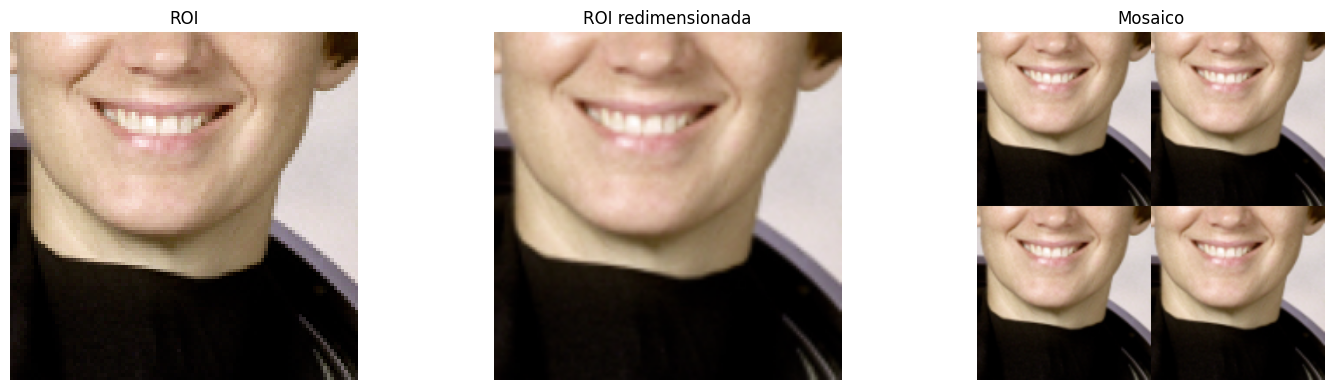

In [ ]:
# Definí los índices de tu región de interés.
y1, y2 = 120, 220 #elegir coordenadas donde x representa las columnas e y las filas
x1, x2 = 180, 280 #desde la fila 120 hasta la 220 y desde la columna 180 hasta la 280

roi = img_rgb[y1:y2, x1:x2] #ROI se define una region de 100x100
roi_grande = cv2.resize(roi, (220, 220)) #toma el recorte y lo agranda a 220x220

# Armá un mosaico 2 x 2.
fila_superior = np.hstack([roi_grande, roi_grande]) #une imágenes horizontalmente
fila_inferior = np.hstack([roi_grande, roi_grande]) #une imágenes horizontalmente
mosaico = np.vstack([fila_superior, fila_inferior]) #une imágenes verticalmente

mostrar_imagenes(
    [roi, roi_grande, mosaico],
    ["ROI", "ROI redimensionada", "Mosaico"],
    figsize=(15, 4),
)


In [ ]:
explicacion_geometria = (
    "Recortar significa seleccionar solo una parte de la imagen original, "
    "mientras que redimensionar significa cambiar el tamaño de una imagen o recorte, "
    "agrandándolo o achicándolo."
)
print(explicacion_geometria)


Recortar significa seleccionar solo una parte de la imagen original, mientras que redimensionar significa cambiar el tamaño de una imagen o recorte, agrandándolo o achicándolo.


Recortar: elegís una parte
Redimensionar: cambiás su tamaño

## Ejercicio 3: Bordes y umbralización

1. Cargá `texto.png` en escala de grises.
2. Aplicá `Canny` con dos pares de umbrales distintos.
3. Cargá `monedas.png` en escala de grises.
4. Segmentá la imagen de monedas con al menos dos umbrales.
5. Compará los resultados y explicá cuál te parece más útil.


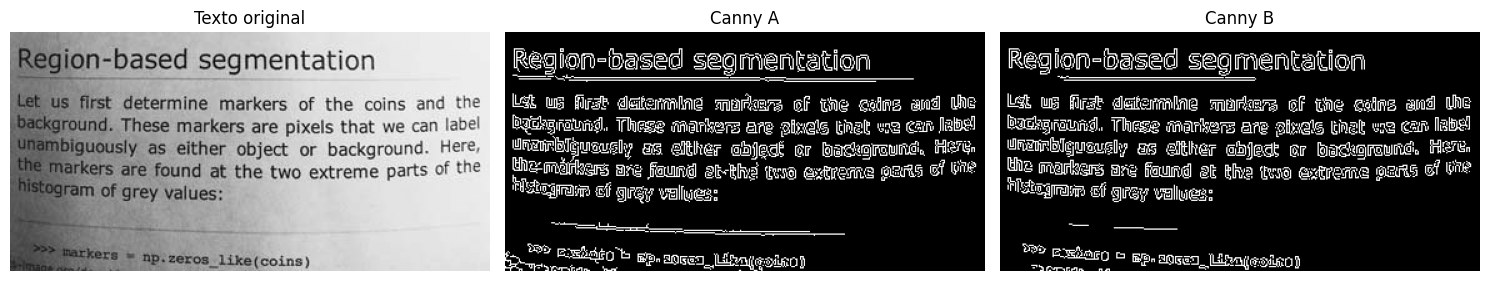

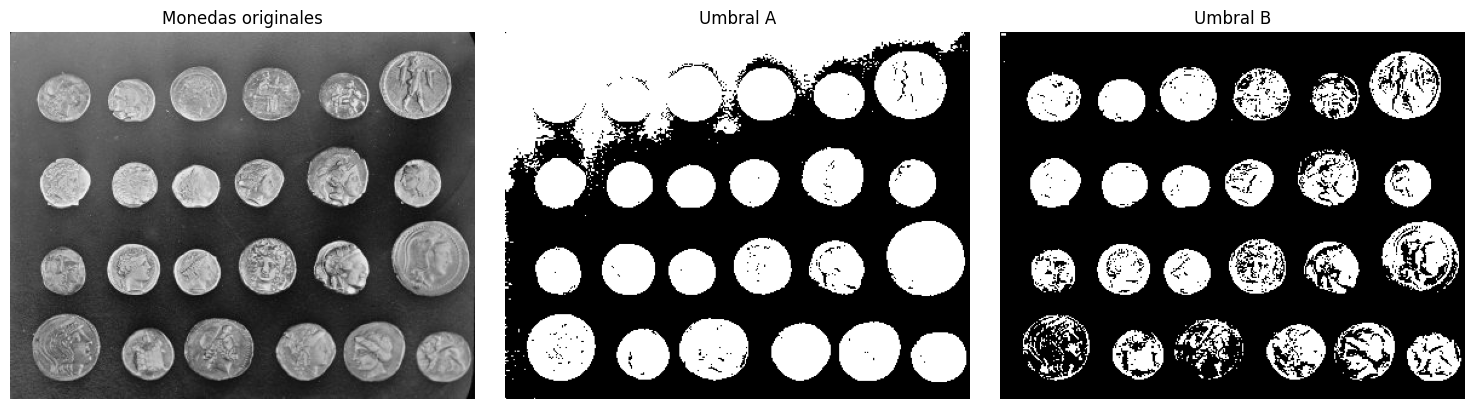

In [ ]:
img_texto = cv2.imread("texto.png", cv2.IMREAD_GRAYSCALE) #para detectar los bordes busco los cambios de intensidad

canny_a = cv2.Canny(img_texto, 50, 150) #detecta los bordes entre los umbrales
canny_b = cv2.Canny(img_texto, 100, 200)

mostrar_imagenes(
    [img_texto, canny_a, canny_b],
    ["Texto original", "Canny A", "Canny B"],
    figsize=(15, 4),
)

img_monedas = cv2.imread("monedas.png", cv2.IMREAD_GRAYSCALE) #idem anterior

seg_a = segmentar_por_umbral(img_monedas, 90) #más píxeles superan el umbral, entonces aparece más blanco
seg_b = segmentar_por_umbral(img_monedas, 140) #menos píxeles lo superan, entonces la segmentación es más estricta

mostrar_imagenes(
    [img_monedas, seg_a, seg_b],
    ["Monedas originales", "Umbral A", "Umbral B"],
    figsize=(15, 4),
)


## Cierre breve

Antes de pasar al laboratorio, revisá si podés responder estas preguntas:

- ¿cuándo conviene mirar canales por separado?
- ¿qué cambia al modificar los umbrales de `Canny`?
- ¿por qué una segmentación por umbral puede funcionar bien en una imagen y mal en otra?

Si todavía dudás en alguna, volvé a los cuadernos anteriores y recuperá las ideas centrales.


1 - Cuando querés analizar cuánto aporta cada color y ver qué zonas se destacan en rojo, verde o azul.

2- Cambia la sensibilidad de detección de bordes:
 - bajos: más bordes, más ruido
 - altos: menos bordes, más fuertes

3- Porque depende de la iluminación, el contraste y la diferencia entre objeto y fondo.